# Multi-Model Switching

## Overview

In this tutorial we look at **runtime model switching**: exchanging one component of a running
co-simulation for an alternative model of the same subsystem, while every other component stays
coupled and keeps advancing.

A `MultiComponent` wraps several interchangeable models under one port interface and keeps exactly
one of them active. `set_switch_regions()` maps an ordered scalar signal onto those models. It
generates boundary events that the hybrid algorithm localizes by bisection, so each switch lands on
the crossing itself rather than merely on a communication point.

The difference is a placement error of up to one macro step, and it does not stay inside the
switching component: the coupled partners integrate against whichever model is active, so a
misplaced switch feeds the wrong dynamics into their inputs.

## Learning Goals

- Declare an ordered switching policy with `set_switch_regions()`.
- Measure that localized switch placement is independent of the macro-step size.
- Understand why region identity is distinct from model identity.
- Understand how hysteresis guards a localized switch against chattering.

## Prerequisites and Setup

This tutorial builds on the earlier advanced tutorials, in particular the hybrid event handling
introduced in *Hybrid Event Chain* and *Internal Event Reporting*. Familiarity with event
indicators, zero-crossing detection, and bisection-based event localization is assumed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from syssimx.core.base import CoSimComponent
from syssimx.core.multi_comp import ModeKey, MultiComponent
from syssimx.core.port import PortSpec, PortType
from syssimx.system.algorithms.hybrid import HybridAlgorithm
from syssimx.system.system import System

## A Minimal Switchable Plant

To make the switch instant measurable, we use a model whose crossing time is known in closed form.
`RampModel` integrates its output at a constant rate, so with $y(0) = 0$ we simply have

$$y(t) = r \, t$$

and the threshold $y = y_\mathrm{sw}$ is reached at exactly $t_\mathrm{sw} = y_\mathrm{sw} / r$.

Two instances with different rates give us two distinguishable modes. Note that the model
implements `snapshot_state()` and `restore_state()`: rollback is what allows the hybrid algorithm
to bisect, and therefore a precondition for any event indicator.

In [2]:
class RampModel(CoSimComponent):
    """Integrates y at a constant rate. Supports rollback, so events can be localized."""

    def __init__(self, name: str, rate: float):
        super().__init__(name, label=name)
        self.rate = rate
        self._y = 0.0
        self.output_specs = {
            "y": PortSpec(name="y", type=PortType.REAL, unit="m", direction="out"),
        }

    def _initialize_component(self, t0: float) -> None:
        self._y = 0.0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self._y += self.rate * dt

    def _update_output_states(self, t=None, event_names=None) -> None:
        self.outputs["y"].set(self._y, t=t)
        self._apply_event_ports(t, event_names)

    def get_state(self):
        return {"y": self._y}

    def set_state(self, state, t: float) -> None:
        self._y = float(state["y"])

    def snapshot_state(self):
        return {"y": self._y}

    def restore_state(self, snapshot, t: float) -> None:
        self._y = float(snapshot["y"])

    def reset(self) -> None:
        self._y = 0.0

The `MultiComponent` subclass registers both models and defines how state is carried across a
switch. Here both modes share the same state format, so `_adapt_state` passes it through
unchanged. In a heterogeneous setup this is where a FEM displacement field would be reduced to a
rigid-body angle, or vice versa.

In [3]:
class SwitchingPlant(MultiComponent):
    """Two ramp models under one interface: SLOW (rate 1) and FAST (rate 4)."""

    def __init__(self, name: str = "Plant", initial_mode: ModeKey = "SLOW"):
        models = {
            "SLOW": RampModel(f"{name}_SLOW", rate=1.0),
            "FAST": RampModel(f"{name}_FAST", rate=4.0),
        }
        super().__init__(name, models=models, initial_mode=initial_mode)
        self._unify_ports()

    def _adapt_state(self, state, target_mode):
        # Both modes store the same physical quantity, so no translation is needed.
        return state.copy()

Port values carry Pint units, so a switching condition has to unwrap the magnitude before
comparing it against a plain float.

In [4]:
def magnitude(value, default: float = 0.0) -> float:
    """Unwrap a port value, which may be a Pint Quantity."""
    if value is None:
        return default
    return float(getattr(value, "magnitude", value))


BREAKPOINT = 0.93  # center of the region boundary
BAND = 0.05        # rising transition is armed at BREAKPOINT + BAND
SWITCH_LEVEL = BREAKPOINT + BAND
T_CROSS = SWITCH_LEVEL  # SLOW has rate 1.0, so y(t) = t
T_END = 2.0

## Declare the Region Map

The signal below has two ordered regions. `SLOW` owns the lower region and `FAST` the upper one.
The nonzero band arms rising and falling transitions at opposite edges, preventing chatter while
allowing every full-band recrossing.

In [5]:
def run(plant: MultiComponent, dt: float, t_end: float = T_END) -> System:
    """Build a one-component system around the plant and simulate it."""
    system = System(name="SwitchingSystem")
    system.add_component(plant)
    system.algorithm = HybridAlgorithm()
    system.algorithm.verbose = False
    system.initialize(t0=0.0)
    system.run(t0=0.0, tf=t_end, dt=dt)
    return system


def switch_times(plant: MultiComponent) -> list[float]:
    """Times at which the wrapper actually changed mode."""
    return [float(event["time"]) for event in plant.sync_events]


def history(system: System, name: str = "Plant") -> tuple[np.ndarray, np.ndarray]:
    """Recorded output trajectory of one component."""
    t_vals, data = system.get_history()[name]
    return np.asarray(t_vals, dtype=float), np.asarray(data["y"], dtype=float)


def shade_regions(ax, breakpoints, band, modes, labels: bool = True) -> None:
    """Draw a region map onto the signal axis: bands shaded, regions labelled."""
    bands = (band,) * len(breakpoints) if isinstance(band, float) else tuple(band)
    for breakpoint, width in zip(breakpoints, bands):
        ax.axhspan(breakpoint - width, breakpoint + width, color="grey", alpha=0.20, lw=0)
        ax.axhline(breakpoint, color="grey", ls="--", lw=0.8)
    if not labels:
        return
    low, high = ax.get_ylim()
    edges = [low, *breakpoints, high]
    for mode, lower, upper in zip(modes, edges, edges[1:]):
        ax.text(
            0.99, 0.5 * (lower + upper), mode,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=9, color="dimgrey",
        )

In [6]:
def build_region_plant() -> SwitchingPlant:
    plant = SwitchingPlant()
    plant.set_switch_regions(
        key=lambda comp: magnitude(comp.outputs["y"].get()),
        breakpoints=(BREAKPOINT,),
        modes=("SLOW", "FAST"),
        band=BAND,
    )
    return plant


coarse_plant = build_region_plant()
coarse_system = run(coarse_plant, dt=0.2)

print(f"analytic crossing : t = {T_CROSS:.4f} s")
print(f"switch applied at : t = {switch_times(coarse_plant)[0]:.4f} s")

analytic crossing : t = 0.9800 s
switch applied at : t = 0.9800 s


The switch sits on the rising edge of the band even though that instant is not a communication point.

## Macro-Step Independence

Run the same region policy with a smaller macro step. The hybrid algorithm detects the generated
boundary crossing, narrows its carried sign-change bracket by bisection, and applies the switch at
the same localized instant.

The region key is evaluated against the **wrapper**, not against the active sub-model, so it reads
the unified output ports and keeps working no matter which mode is active.

In [7]:
fine_plant = build_region_plant()
fine_system = run(fine_plant, dt=0.073)

print(f"analytic crossing : t = {T_CROSS:.4f} s")
print(f"switch applied at : t = {switch_times(fine_plant)[0]:.4f} s")

analytic crossing : t = 0.9800 s
switch applied at : t = 0.9800 s


The switch now sits on the crossing itself, to the tolerance of the bisection, even though the
communication grid never contains that instant.

## Comparing the Trajectories

The left panel below plots both runs against the exact solution and draws the region map behind
them: the dashed line is the breakpoint, the grey strip is its band, and the labels name the model
that owns each region. The exact trajectory ramps at rate 1 until $t_\mathrm{sw}$ and at rate 4
afterwards.

The right panel zooms onto the transition. The two blue lines are the communication points of the
coarse run that bracket the crossing, and the switch (red star) is applied strictly between them.

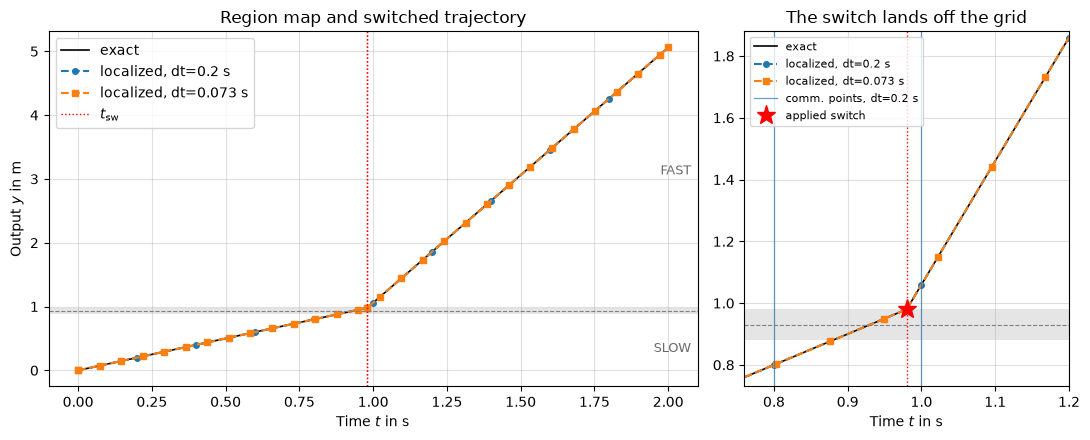

In [8]:
def exact_trajectory(t: np.ndarray) -> np.ndarray:
    """Analytic y(t): rate 1 before the crossing, rate 4 after it."""
    return np.where(t <= T_CROSS, t, SWITCH_LEVEL + 4.0 * (t - T_CROSS))


t_coarse, y_coarse = history(coarse_system)
t_fine_run, y_fine = history(fine_system)
t_dense = np.linspace(0.0, T_END, 400)

fig, (ax_full, ax_zoom) = plt.subplots(
    1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [2, 1]}
)
for ax in (ax_full, ax_zoom):
    ax.plot(t_dense, exact_trajectory(t_dense), "k-", lw=1.2, label="exact")
    ax.plot(t_coarse, y_coarse, "o--", ms=4, label="localized, dt=0.2 s")
    ax.plot(t_fine_run, y_fine, "s--", ms=4, label="localized, dt=0.073 s")
    ax.axvline(T_CROSS, color="red", ls=":", lw=1.0)
    ax.set_xlabel(r"Time $t$ in s")
    ax.grid(True, alpha=0.4)

ax_full.set_ylabel(r"Output $y$ in m")
ax_full.axvline(T_CROSS, color="red", ls=":", lw=1.0, label=r"$t_\mathrm{sw}$")
ax_full.set_title("Region map and switched trajectory")
ax_full.legend(loc="upper left")
shade_regions(ax_full, (BREAKPOINT,), BAND, ("SLOW", "FAST"))

# The coarse run advances on a 0.2 s grid; these two points bracket the crossing.
left_point = float(np.floor(T_CROSS / 0.2) * 0.2)
ax_zoom.axvline(left_point, color="tab:blue", lw=0.9, alpha=0.7, label="comm. points, dt=0.2 s")
ax_zoom.axvline(left_point + 0.2, color="tab:blue", lw=0.9, alpha=0.7)
ax_zoom.plot(switch_times(coarse_plant)[:1], [SWITCH_LEVEL], "r*", ms=14, label="applied switch")
ax_zoom.set_xlim(T_CROSS - 0.22, T_CROSS + 0.22)
ax_zoom.set_ylim(SWITCH_LEVEL - 0.25, SWITCH_LEVEL + 0.9)
ax_zoom.set_title("The switch lands off the grid")
ax_zoom.legend(loc="upper left", fontsize=8)
shade_regions(ax_zoom, (BREAKPOINT,), BAND, ("SLOW", "FAST"), labels=False)

fig.tight_layout()
plt.show()

## Placement Across Macro-Step Sizes

The localized switch is limited by the bisection tolerance rather than by the macro step. Repeating
the run below verifies that placement remains stable over several communication grids.

In [9]:
step_sizes = [0.4, 0.2, 0.1, 0.05, 0.025]
placement_errors = []

for dt in step_sizes:
    plant = build_region_plant()
    run(plant, dt=dt)
    placement_errors.append(abs(switch_times(plant)[0] - T_CROSS))

for dt, error in zip(step_sizes, placement_errors):
    print(f"dt = {dt:6.3f} s   localized error = {error:.3e} s")

dt =  0.400 s   localized error = 3.052e-07 s
dt =  0.200 s   localized error = 3.052e-07 s
dt =  0.100 s   localized error = 3.052e-07 s
dt =  0.050 s   localized error = 3.052e-07 s
dt =  0.025 s   localized error = 3.052e-07 s


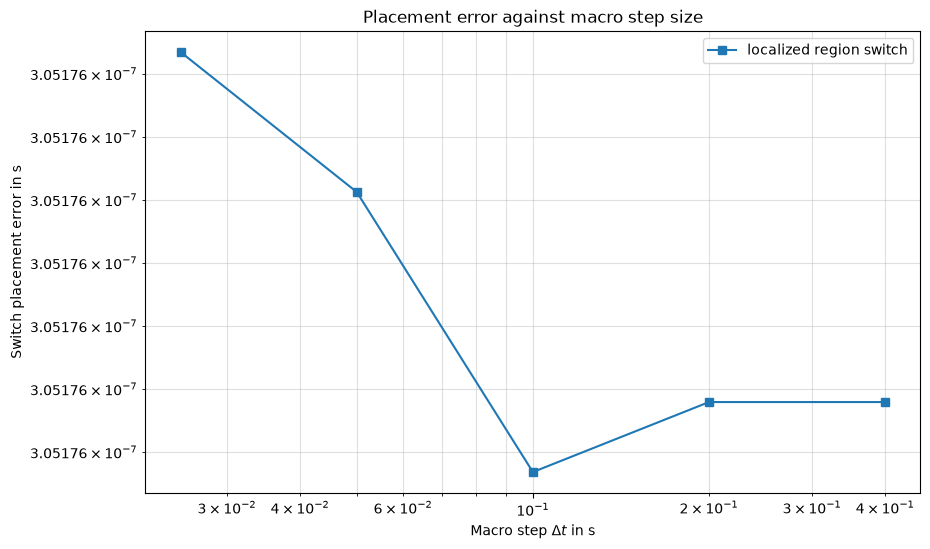

In [10]:
plt.figure(figsize=(10, 6))
plt.loglog(step_sizes, placement_errors, "s-", label="localized region switch")
plt.xlabel(r"Macro step $\Delta t$ in s")
plt.ylabel("Switch placement error in s")
plt.title("Placement error against macro step size")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.show()

The localized error sits flat
at the bisection tolerance, a few times $10^{-7}\,\mathrm{s}$ here, regardless of the macro step.

This matters beyond the switching component itself. Any partner coupled to this plant integrates
against whichever model is active, so a switch placed up to one macro step late injects the wrong
dynamics into the partners' inputs for that interval. Localizing the switch removes that error
term from the whole coupled system, not only from the component that switched.

## What Happens Under the Hood

A generated region boundary is registered in the same indicator registry that physical state
events use, so the existing hybrid machinery carries it:

1. `evaluate_event_indicators()` returns the active sub-model's indicators **and** the wrapper's
   generated boundary indicators, merged into one mapping.
2. The hybrid algorithm takes a rolled-back trial step and compares the values on both sides of the
   interval. During that trial step mode switching is suppressed, because a state snapshot is only
   valid for the model that produced it.
3. When a crossing is found, bisection narrows the interval to the tolerance.
4. The state is advanced to the located instant, and only then is the event handled.
5. `MultiComponent` handles the event by first passing any physical events to the outgoing model,
   and then performing the mode switch, so the state handed over is the post-event state.

Because each boundary is an event, it also appears as an EVENT output port on the wrapper, and can be
observed or connected like any other event.

In [11]:
print("registered indicators :", list(coarse_plant.event_indicators))
print("region configuration  :", coarse_plant.switch_regions)
print("event output port     :", "region_boundary_0" in coarse_plant.output_specs)
print("switch record         :", coarse_plant.sync_events)

registered indicators : ['region_boundary_0']
region configuration  : SwitchRegions(key=<function build_region_plant.<locals>.<lambda> at 0x0000024B2886E160>, modes=('SLOW', 'FAST'), boundaries=(RegionBoundary(index=0, breakpoint=0.93, band=0.05),))
event output port     : True
switch record         : [{'time': 0.9800003051757811, 'from_mode': 'SLOW', 'to_mode': 'FAST'}]


## Regions Are Not Models

A region map is an ordered partition of the switching signal, and it is the *region* that carries
runtime identity, not the model key. The same model may therefore own several regions. The map
below has three regions but only two models: `SLOW` runs below the lower breakpoint and again above
the upper one, with `FAST` in between.

In [12]:
identity_plant = SwitchingPlant()
identity_plant.set_switch_regions(
    key=lambda comp: magnitude(comp.outputs["y"].get()),
    breakpoints=(0.5, 1.5),
    modes=("SLOW", "FAST", "SLOW"),
    band=BAND,
)
identity_system = run(identity_plant, dt=0.1)

t_up = 0.5 + BAND                             # SLOW ramps at rate 1 from y = 0
t_down = t_up + ((1.5 + BAND) - t_up) / 4.0   # FAST ramps at rate 4 to the upper band edge
print(f"expected switches : t = {t_up:.4f} s and t = {t_down:.4f} s")
for record in identity_plant.sync_events:
    print(
        f"switch applied at : t = {record['time']:.4f} s   "
        f"{record['from_mode']} -> {record['to_mode']}"
    )
print(f"final region index: {identity_plant.active_region_index}")
print(f"final active mode : {identity_plant.active_mode}")

expected switches : t = 0.5500 s and t = 0.8000 s
switch applied at : t = 0.5500 s   SLOW -> FAST
switch applied at : t = 0.8000 s   FAST -> SLOW
final region index: 2
final active mode : SLOW


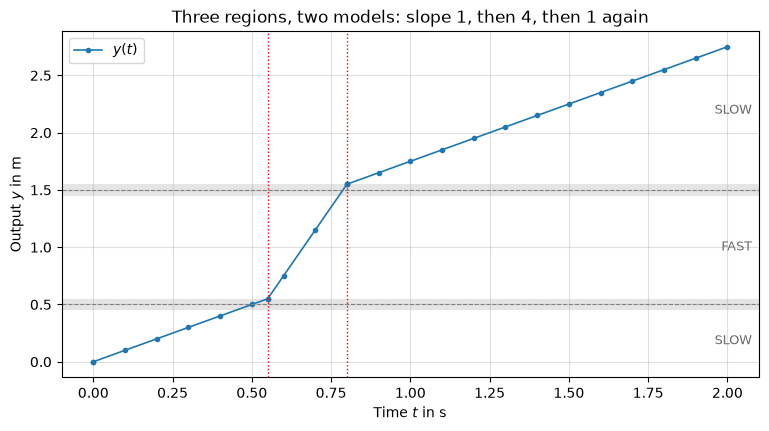

In [13]:
t_identity, y_identity = history(identity_system)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_identity, y_identity, "o-", ms=3, lw=1.2, color="tab:blue", label=r"$y(t)$")
for record in identity_plant.sync_events:
    ax.axvline(float(record["time"]), color="red", ls=":", lw=1.0)
ax.set_xlabel(r"Time $t$ in s")
ax.set_ylabel(r"Output $y$ in m")
ax.set_title("Three regions, two models: slope 1, then 4, then 1 again")
ax.grid(True, alpha=0.4)
ax.legend(loc="upper left")
shade_regions(ax, (0.5, 1.5), BAND, ("SLOW", "FAST", "SLOW"))
plt.show()

Region 0 and region 2 activate the *same* `SLOW` instance. It is not resumed from the state it held
when it was deactivated: the wrapper transfers the outgoing `FAST` state through `_adapt_state()`
into it, which is why the trajectory stays continuous across both switches and only its slope
changes.

This is why the wrapper reports an `active_region_index` next to `active_mode`. Two regions can
report the same mode while being distinct runtime states, and a transition always goes to an
*adjacent* region, never as a jump across the map.

## Guarding Against Chattering

A boundary is only useful if the signal is not free to oscillate around it. `set_switch_regions()`
therefore requires a nonzero `band` at every boundary and arms only its far edge: while region $i$
is active the boundary triggers at `breakpoint + band`, and once region $i+1$ is active it triggers
at `breakpoint - band`. Motion inside the band retains the active region, and a full-band
recrossing is a real transition that is never suppressed based on elapsed time.

The plant below is the worst case for that rule. `UP` ramps at $+1\,\mathrm{m/s}$ and `DOWN` at
$-1\,\mathrm{m/s}$, so whichever model is active immediately drives the signal back towards the
boundary it just crossed. Nothing but the band bounds the switching rate here, and it does: the
signal has to travel a full band width in each direction, so the dwell time in a region cannot fall
below $2\,\text{band} / |\text{rate}|$.

In [14]:
class BangBangPlant(MultiComponent):
    """Each mode drives the switching signal straight back across its own boundary."""

    def __init__(self, name: str = "Chatter"):
        models = {
            "UP": RampModel(f"{name}_UP", rate=1.0),
            "DOWN": RampModel(f"{name}_DOWN", rate=-1.0),
        }
        super().__init__(name, models=models, initial_mode="UP")
        self._unify_ports()

    def _adapt_state(self, state, target_mode):
        return state.copy()


def run_bang_bang(band: float, dt: float = 0.05) -> tuple[BangBangPlant, System]:
    """Declare a single boundary with the given band and simulate the plant."""
    plant = BangBangPlant()
    plant.set_switch_regions(
        key=lambda comp: magnitude(comp.outputs["y"].get()),
        breakpoints=(0.5,),
        modes=("UP", "DOWN"),
        band=band,
    )
    return plant, run(plant, dt=dt)


narrow_plant, narrow_system = run_bang_bang(band=0.05)
wide_plant, wide_system = run_bang_bang(band=0.25)

for band, plant in ((0.05, narrow_plant), (0.25, wide_plant)):
    times = switch_times(plant)
    dwell = float(np.diff(times)[0])
    print(
        f"band = {band:.2f} m : {len(times):2d} switches in {T_END:.0f} s, "
        f"dwell = {dwell:.3f} s (expected {2 * band:.3f} s)"
    )

band = 0.05 m : 15 switches in 2 s, dwell = 0.100 s (expected 0.100 s)
band = 0.25 m :  3 switches in 2 s, dwell = 0.500 s (expected 0.500 s)


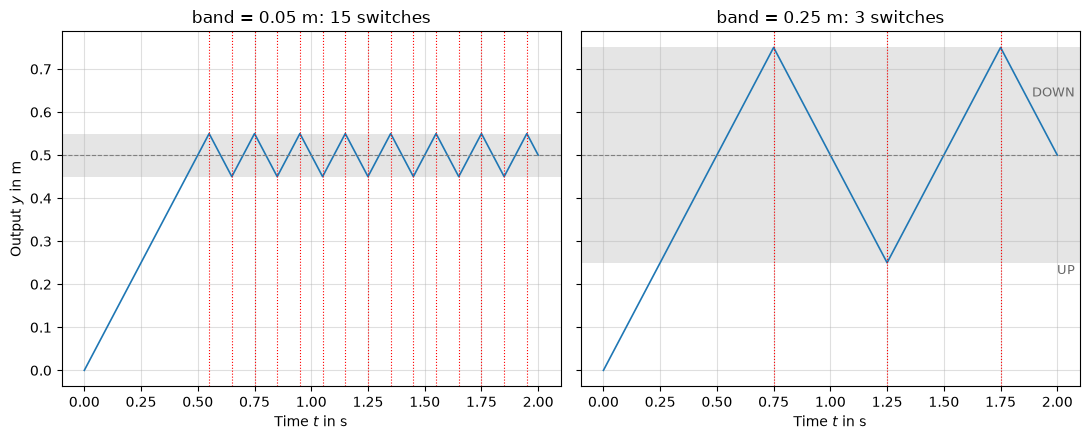

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
runs = ((0.05, narrow_plant, narrow_system), (0.25, wide_plant, wide_system))

for ax, (band, plant, system) in zip(axes, runs):
    t_vals, y_vals = history(system, name=plant.name)
    ax.plot(t_vals, y_vals, "-", lw=1.2, color="tab:blue")
    for switch in switch_times(plant):
        ax.axvline(switch, color="red", ls=":", lw=0.8)
    ax.set_xlabel(r"Time $t$ in s")
    ax.set_title(f"band = {band:.2f} m: {len(switch_times(plant))} switches")
    ax.grid(True, alpha=0.4)
    shade_regions(ax, (0.5,), band, ("UP", "DOWN"), labels=ax is axes[1])

axes[0].set_ylabel(r"Output $y$ in m")
fig.tight_layout()
plt.show()

Both runs switch on every full-band recrossing, as they must, because each one is a genuine
transition of the switching signal rather than numerical noise. What the band controls is how far
the signal has to travel before the next transition is armed, so it puts a lower bound on the dwell
time in a region without ever discarding a valid crossing.

In a real model the band is therefore chosen from the physics and not from the macro step. It
should be wider than the ripple the switching signal carries inside a region, and narrower than the
excursion that genuinely means the other model should take over.

## Summary

- `set_switch_regions()` is the public model-selection API for `MultiComponent`: an ordered map of
  breakpoints, models, and hysteresis bands over one scalar runtime signal.
- Generated boundaries are zero crossings, so the hybrid algorithm localizes them by bisection and
  switch placement is governed by the localization tolerance rather than the macro-step size.
- The switch is applied while handling the localized event, after physical events have been passed
  to the outgoing model, which keeps the state handover consistent.
- Regions, not model keys, carry runtime identity. One model may own several regions, and every
  transition goes to an adjacent region.
- Region boundary bands prevent chatter without suppressing valid rapid recrossings, and the band
  width sets the minimum dwell time in a region.
- Because coupled partners keep running across the switch, reducing the placement error benefits
  the whole system, not just the component that switched.